# L2 regularization (Ridge regression)

Preparing the data


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [65]:
df = pd.read_csv('./data/another_advertising.csv')
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [66]:
X = df.drop('sales', axis=1)

In [67]:
y = df['sales']

In [68]:
from sklearn.preprocessing import PolynomialFeatures

In [69]:
poly_converter = PolynomialFeatures(degree=3, include_bias=False)
poly_features = poly_converter.fit_transform(X)

In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [72]:
X.shape, poly_features.shape, X_train.shape, X_test.shape

((200, 3), (200, 19), (140, 19), (60, 19))

Scaling the data

In [73]:
from sklearn.preprocessing import StandardScaler

In [74]:
scaler = StandardScaler()

Scaling **only** the training data, scaling the test data would lead to data leakage.

In [75]:
scaler.fit(X_train)

StandardScaler()

In [76]:
X_train = scaler.transform(X_train)

In [77]:
X_test = scaler.transform(X_test)

In [78]:
poly_features[0]

array([2.30100000e+02, 3.78000000e+01, 6.92000000e+01, 5.29460100e+04,
       8.69778000e+03, 1.59229200e+04, 1.42884000e+03, 2.61576000e+03,
       4.78864000e+03, 1.21828769e+07, 2.00135918e+06, 3.66386389e+06,
       3.28776084e+05, 6.01886376e+05, 1.10186606e+06, 5.40101520e+04,
       9.88757280e+04, 1.81010592e+05, 3.31373888e+05])

In [79]:
X_train[0]

array([ 0.49300171, -0.33994238,  1.61586707,  0.28407363, -0.02568776,
        1.49677566, -0.59023161,  0.41659155,  1.6137853 ,  0.08057172,
       -0.05392229,  1.01524393, -0.36986163,  0.52457967,  1.48737034,
       -0.66096022, -0.16360242,  0.54694754,  1.37075536])

## Ridge Regression

Notes on sklearn ridge regression:

- it refers to lambda as alpha within the class call
- it follows the convention that *higher* return values are *better* than lower return values (by using the *negative* RMSE)

In [80]:
from sklearn.linear_model import Ridge

In [81]:
ridge_model = Ridge(alpha=10)

In [82]:
ridge_model.fit(X_train, y_train)

Ridge(alpha=10)

In [83]:
test_predictions = ridge_model.predict(X_test)

In [84]:
def model_error_evaluation():
    from sklearn import metrics
    mae = metrics.mean_absolute_error(y_test, test_predictions)
    mse = metrics.mean_squared_error(y_test, test_predictions)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, test_predictions))
    print('MAE', round(mae, 3))
    print('MSE', round(mse, 3))
    print('RMSE', round(rmse, 3))
model_error_evaluation()

MAE 0.577
MSE 0.8
RMSE 0.895


Now let's compare the model's performance against the training set

In [85]:
train_predictions = ridge_model.predict(X_train)

def model_error_evaluation():
    from sklearn import metrics
    mae = metrics.mean_absolute_error(y_train, train_predictions)
    mse = metrics.mean_squared_error(y_train, train_predictions)
    rmse = np.sqrt(metrics.mean_squared_error(y_train, train_predictions))
    print('MAE', round(mae, 3))
    print('MSE', round(mse, 3))
    print('RMSE', round(rmse, 3))
model_error_evaluation()

MAE 0.529
MSE 0.721
RMSE 0.849


In [86]:
from sklearn.linear_model import RidgeCV

In [87]:
ridge_cv_model = RidgeCV(alphas=(0.1, 1.0, 10.0), scoring='neg_mean_absolute_error')

In [88]:
ridge_cv_model.fit(X_train, y_train)

RidgeCV(scoring='neg_mean_absolute_error')

In [89]:
ridge_cv_model.alpha_

np.float64(0.1)

In [90]:
test_predictions = ridge_cv_model.predict(X_test)

In [91]:
def model_error_evaluation():
    from sklearn import metrics
    mae = metrics.mean_absolute_error(y_test, test_predictions)
    mse = metrics.mean_squared_error(y_test, test_predictions)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, test_predictions))
    print('MAE', round(mae, 3))
    print('MSE', round(mse, 3))
    print('RMSE', round(rmse, 3))
model_error_evaluation()

MAE 0.427
MSE 0.382
RMSE 0.618


In [92]:
train_predictions = ridge_cv_model.predict(X_train)

In [93]:
def model_error_evaluation():
    from sklearn import metrics
    mae = metrics.mean_absolute_error(y_train, train_predictions)
    mse = metrics.mean_squared_error(y_train, train_predictions)
    rmse = np.sqrt(metrics.mean_squared_error(y_train, train_predictions))
    print('MAE', round(mae, 3))
    print('MSE', round(mse, 3))
    print('RMSE', round(rmse, 3))
model_error_evaluation()

MAE 0.309
MSE 0.221
RMSE 0.47


In [94]:
ridge_cv_model.coef_

array([ 5.40769392,  0.5885865 ,  0.40390395, -6.18263924,  4.59607939,
       -1.18789654, -1.15200458,  0.57837796, -0.1261586 ,  2.5569777 ,
       -1.38900471,  0.86059434,  0.72219553, -0.26129256,  0.17870787,
        0.44353612, -0.21362436, -0.04622473, -0.06441449])

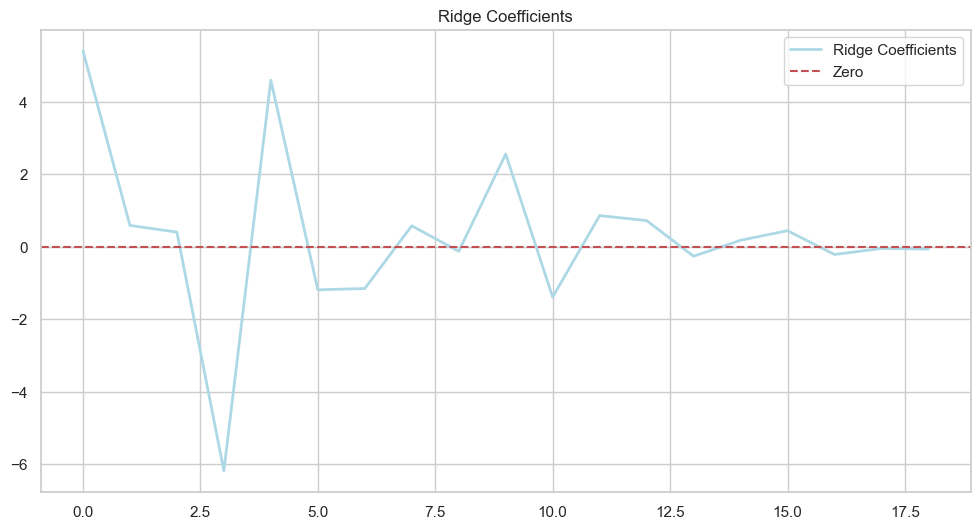

In [95]:
plt.figure(figsize=(12,6))
plt.plot(ridge_cv_model.coef_, color='lightblue', linewidth=2, label='Ridge Coefficients')
plt.axhline(y=0, color='r', linestyle='--', label='Zero')
plt.legend(loc='best')
plt.title('Ridge Coefficients')
plt.show()